# Experiment 4: Noise Models and Image Restoration using Filters

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Arithmetic Mean Filter

In [ ]:
def arithmetic_mean_filter(image, kernel_size):
    """Applies arithmetic mean filter using a sliding window."""
    pad = kernel_size // 2
    padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            output[i, j] = np.mean(region)
    return np.clip(output, 0, 255).astype(np.uint8)

# Midpoint filter

In [ ]:
def midpoint_filter(image, kernel_size):
    """Applies midpoint filter: average of min and max in window."""
    pad = kernel_size // 2
    padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            min_val, max_val = np.min(region), np.max(region)
            output[i, j] = (min_val + max_val) / 2
    return np.clip(output, 0, 255).astype(np.uint8)

# Alpha Trimmed Mean Filter

In [ ]:
def alpha_trimmed_mean_filter(image, kernel_size, d):
    """Applies alpha-trimmed mean filter: trim d/2 lowest/highest, mean rest."""
    if d % 2 != 0 or d >= kernel_size**2:
        raise ValueError("d must be even and less than window size squared")
    pad = kernel_size // 2
    padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros_like(image, dtype=np.float32)
    trim_count = d // 2
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size].flatten()
            sorted_region = np.sort(region)
            trimmed = sorted_region[trim_count : -trim_count] if trim_count > 0 else sorted_region
            output[i, j] = np.mean(trimmed)
    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
# Load grayscale noisy image (add noise if original)
img = cv2.imread('/content/drive/MyDrive/Colab Notebooks/IPCV/noisy_image.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Load a noisy grayscale image as 'noisy_image.jpg'")
    exit()


In [ ]:
# Parameters from lab (adjust as needed)
kernel_size = 3  # m x n window, e.g., 3x3
d = 4  # Trimming for alpha-trimmed (even)

# Apply filters
mean_filtered = arithmetic_mean_filter(img, kernel_size)
midpoint_filtered = midpoint_filter(img, kernel_size)
alpha_filtered = alpha_trimmed_mean_filter(img, kernel_size, d)

/tmp/ipykernel_5758/3114746077.py:25: RuntimeWarning: overflow encountered in scalar add
  output[i, j] = (min_val + max_val) / 2


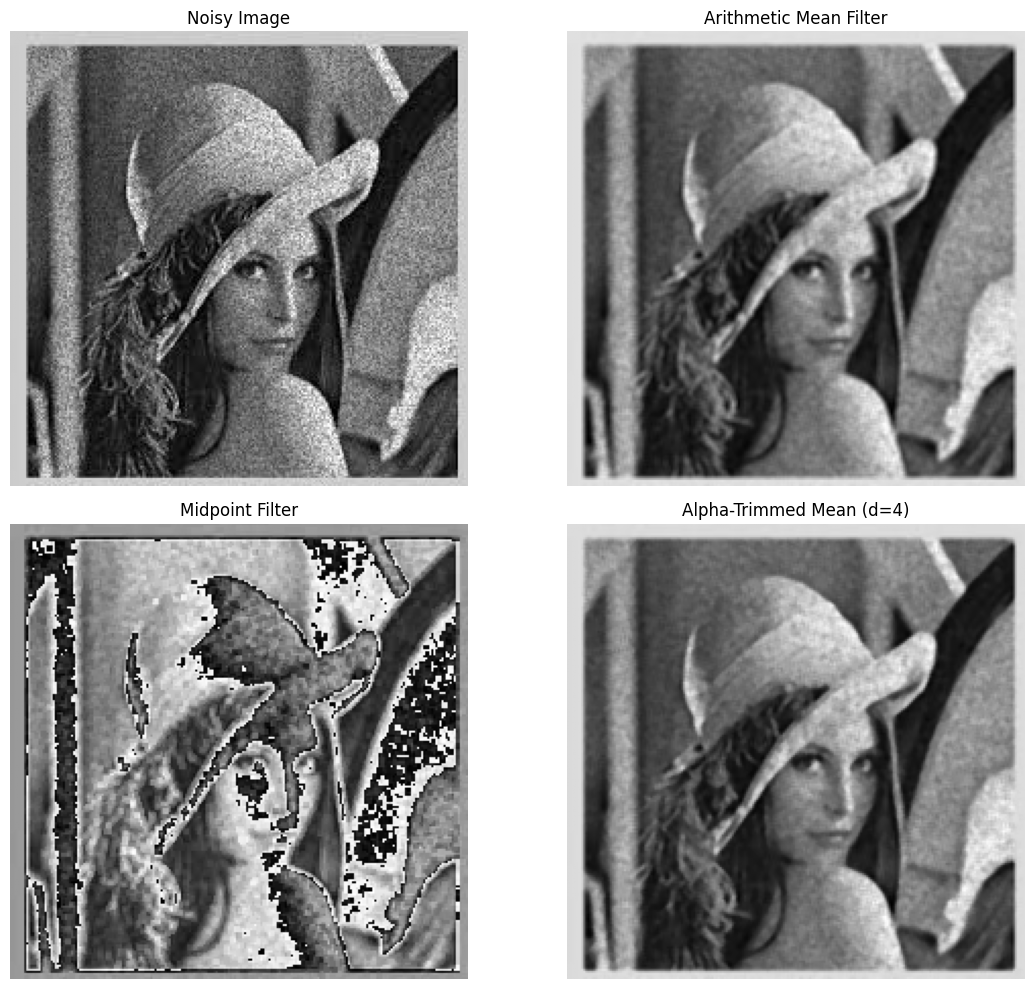

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].imshow(img, cmap='gray')
axes[0,0].set_title('Noisy Image')
axes[0,1].imshow(mean_filtered, cmap='gray')
axes[0,1].set_title('Arithmetic Mean Filter')
axes[1,0].imshow(midpoint_filtered, cmap='gray')
axes[1,0].set_title('Midpoint Filter')
axes[1,1].imshow(alpha_filtered, cmap='gray')
axes[1,1].set_title(f'Alpha-Trimmed Mean (d={d})')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()